# Figure 5a

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

experiment_name = 'sac_c10+n-10_b100'

eval_data_path = os.path.join('experiments', experiment_name, 'training_data.csv')

df = pd.read_csv(eval_data_path)
rewards = []
experiment_numbers = []
index_value = df.index[df['timestep'] == 0].tolist()

for i in range(len(index_value)):
    if i != len(index_value) - 1:
        start_index = index_value[i]
        end_index = index_value[i + 1] - 1

        subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
        reward_sum = subset_df['reward'].sum()
        rewards.append(reward_sum)
        experiment_number = subset_df['experiment_number'].iloc[0]
        experiment_numbers.append(experiment_number)

# Apply moving average smoothing only to rewards
smoothed_rewards = moving_average(rewards, window_size=100)


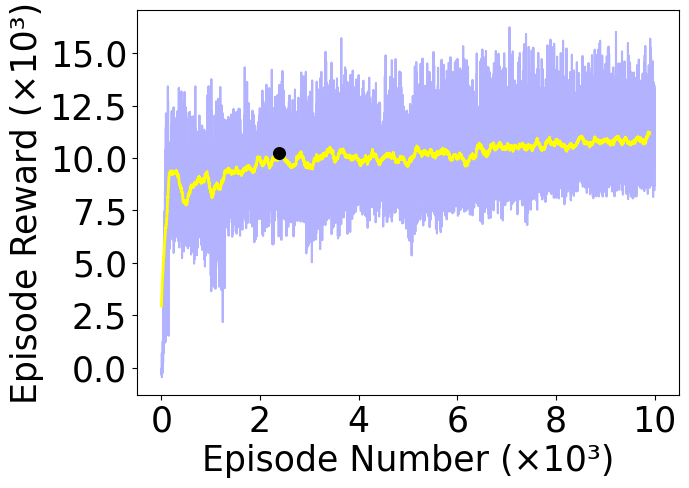

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.ndimage import gaussian_filter1d


# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"


# Plot the figure
plt.figure(figsize=(7, 5))
plt.plot(np.array(experiment_numbers)/1e3, np.array(rewards)/1e3, color='blue', alpha=0.3) 
plt.plot(np.array(experiment_numbers[:len(smoothed_rewards)])/1e3, np.array(smoothed_rewards)/1e3, color='yellow', linewidth=2)

# Scatter plot for local maxima
plt.scatter(2380.0/1e3 , 10256.2/1e3, color='black', zorder=4, s=70)

plt.xlabel("Episode Number (×10³)", fontsize=25)
plt.ylabel("Episode Reward (×10³)", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Save figure
figure_path = os.path.join('figures', 'figure5', 'figure5a.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()


# Figure5b

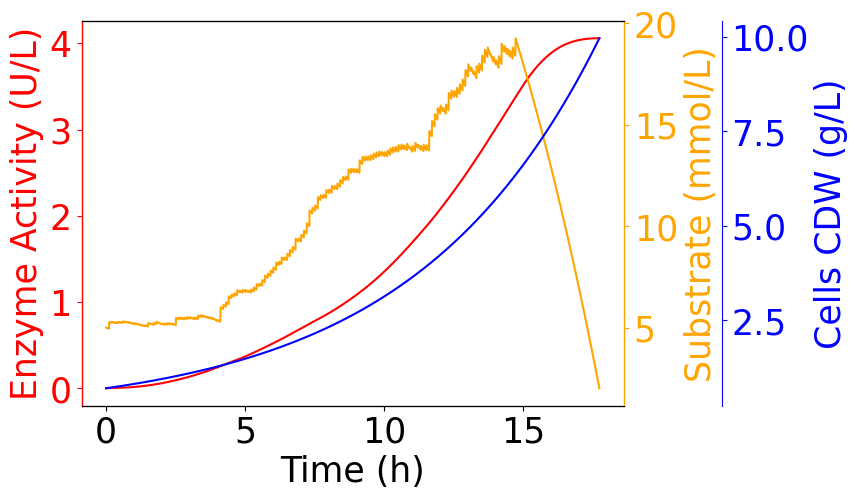

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO, SAC
import utils


best_experiment_name = 'sac_c10+n-10_b100'
best_model_path = os.path.join('experiments', best_experiment_name, 'model', 'best_model.zip')

loaded_model = SAC.load(best_model_path)
sub_action = []
# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0
change_in_enzyme = []
for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            model_input = np.array([i, E, X])
            action = loaded_model.predict(model_input, deterministic=False)
            substrate_action = action[0][0]
            sub_action.append(substrate_action)
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO * 1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    change_in_enzyme.append(delE)
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
S_C_R = (S/X)

# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"
fig, ax1 = plt.subplots(figsize=(7, 5))

# Plot Enzyme Activity
ax1.plot(tvec[0:i], E, color="red", label="Enzyme Activity (U/L)")

# Substrate data on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S*1e3, color="orange", label="Substrate (mmol/L)")

# Cells data on tertiary y-axis
ax3 = ax1.twinx()
ax3.plot(tvec[0:i], X, color="blue", label="Cells CDW (g/L)")
ax3.spines['right'].set_position(('axes', 1.18))

# Axis labels with fontsize
ax1.set_ylabel("Enzyme Activity (U/L)", color="red", fontsize=25)
ax1.set_xlabel("Time (h)", fontsize=25)
ax2.set_ylabel("Substrate (mmol/L)", color="orange", fontsize=25)
ax3.set_ylabel("Cells CDW (g/L)", color="blue", fontsize=25)

# Tick parameters with fontsize and colors
ax1.tick_params(axis='y', colors="red", labelsize=25)
ax2.tick_params(axis='y', colors="orange", labelsize=25)
ax3.tick_params(axis='y', colors="blue", labelsize=25)
ax1.tick_params(axis='x', labelsize=25)

# Spines colors
ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")

# Save the figure
figure_path = os.path.join('figures', 'figure5', 'figure5b.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)

Text(0, 0.5, '$\\frac{dE}{dt}$')

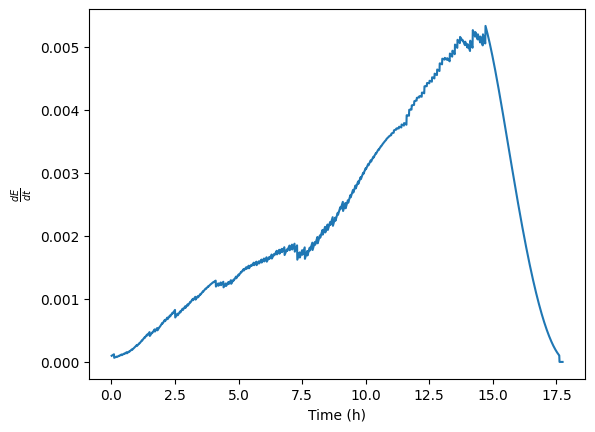

In [2]:
plt.plot(tvec[:len(change_in_enzyme)], change_in_enzyme)
plt.xlabel("Time (h)")
plt.ylabel(r"$\frac{dE}{dt}$")

# Figure5c

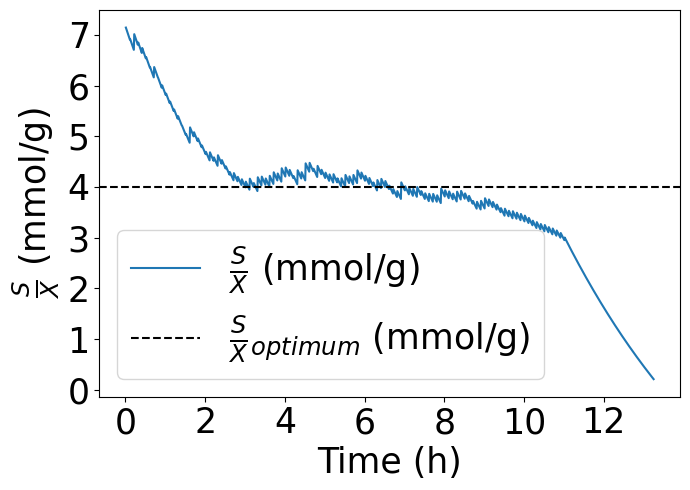

In [40]:
# Second plot: Substrate to Cell Ratio
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
plt.figure(figsize=(7, 5))
plt.plot(tvec[:len(S_C_R)], S_C_R*1e3, label=r"$\frac{S}{X}$ (mmol/g)")
plt.axhline(y=config.OPT_SUB_CELL_RATIO*1e3, color="black", linestyle="--", label=r"$\frac{S}{X}_{optimum}$ (mmol/g)")
plt.xlabel("Time (h)", fontsize=25)
plt.ylabel(r"$\frac{S}{X}$ (mmol/g)", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.tight_layout()
figure_path = os.path.join('figures', 'figure5', 'figure5c.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()
# Save the figure


# Figure5d

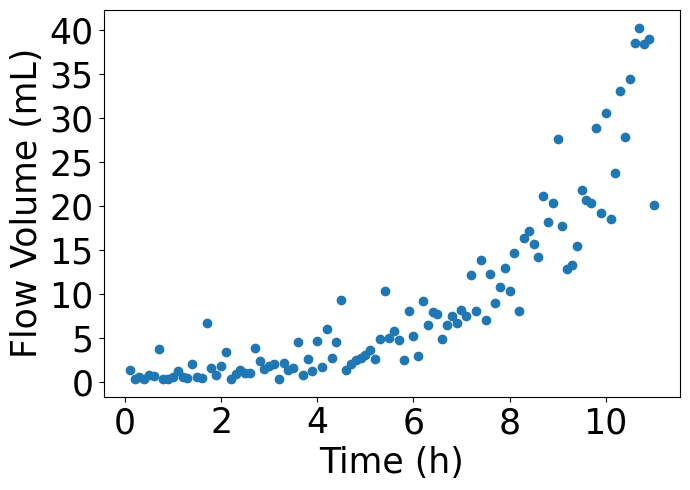

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"

plt.figure(figsize=(7, 5))

# Scale X-axis values
scaled_tvec = [value * 10 for value in tvec[:len(sub_action)]]

# Multiply Y-axis values by 1e3
plt.scatter(scaled_tvec, np.array(sub_action) * 1e3)

plt.xlabel("Time (h)", fontsize=25)
plt.ylabel("Flow Volume (mL)", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.tight_layout()

# Save the figure
figure_path = os.path.join('figures', 'figure5', 'figure5d.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)

plt.show()

